# Chapter 47 — Long-Period Radio Transients

!!! info "Before you start"
    **Prerequisites:** Ch 13 (Pulsars) · Ch 18 (Fast Radio Bursts) · Ch 20 (Pulsar Timing Arrays) · **~60 min** · **Advanced**

In **Chapter 13** we met the pulsar — a rotating neutron star whose period is
milliseconds to seconds, well above the "death line" where rotation-powered radio
emission is thought to switch off. In **Chapter 18** we saw fast radio bursts:
millisecond flashes from other galaxies. This chapter sits at the boundary of both:
a class of sources that **nobody expected to exist** — pulsing on timescales of
*minutes to hours*, far slower than any known pulsar, many sitting well
*below* the death line — yet unmistakably emitting coherent radio pulses.

They are the **long-period radio transients (LPTs)**, and their physical nature
is still actively debated. The latest entry — **ASKAP J1745−5051** (Rose et al.
2026) — has just been identified as an accreting magnetic white-dwarf binary
(a likely polar — an accreting magnetic white-dwarf binary), its ~1.3-hour pulses locked to the *orbital* period, not a neutron
star spin. It is a remarkable reminder that "radio pulsar" no longer means only
"rotating neutron star."

### Learning goals

By the end of this chapter you will be able to:

- recount the discovery arc from GCRT J1745−3009 (2005) through the current zoo
  of LPTs (2022–2026) and cite the defining papers;
- describe the **$P$–$\dot P$ diagram** and the **death line**, and explain why
  LPTs are anomalous within the neutron-star framework;
- compute the **surface magnetic field** and **characteristic age** of a pulsar
  from its period and period derivative;
- simulate a long-period, modestly dispersed Galactic transient and contrast
  it with an FRB dynamic spectrum;
- **recover an unknown LPT period** by running `epoch_folding_search` on a
  collapsed time series and display the **folded pulse profile** with `fold_profile`;
- summarise the three competing models (ultra-long-period magnetar, isolated
  magnetic white dwarf, WD+M-dwarf binary) and state which observational signatures
  distinguish them.


## 1. The story: a zoo that shouldn't exist

The first hint came in 2005. **Hyman et al.** reported a source at the Galactic
Centre — **GCRT J1745−3009** — that emitted five 10-minute bursts separated by
77 minutes, then disappeared. No explanation fit. It did not recur.

> **Hyman, S. D. et al. (2005).** *A powerful bursting radio source towards the
> Galactic Centre.* **Nature 434, 50.**
> [DOI: 10.1038/nature03400](https://doi.org/10.1038/nature03400)

Seventeen years passed. Then, in a single annus mirabilis, the field broke open.

> **Hurley-Walker, N. et al. (2022).** *A radio transient with unusually slow
> periodic emission.* **Nature 601, 526.**
> [DOI: 10.1038/s41586-021-04272-x](https://doi.org/10.1038/s41586-021-04272-x)

**GLEAM-X J162759.5−523504.3** ("GLEAM-X J1627") pulsed every **18.18 minutes**
in MWA data from 2018. The pulse width was ~30–60 s; the source was bright in
linear polarisation and strongly frequency-dependent. As a rotation-powered neutron
star its inferred $B$-field ($\sim 10^{15}$ G) would be super-magnetar; the
authors proposed it as an **ultra-long-period magnetar**. The class was born.

> **Hurley-Walker, N. et al. (2023).** *A long-period radio transient active for
> three decades.* **Nature 619, 487.**
> [DOI: 10.1038/s41586-023-06202-5](https://doi.org/10.1038/s41586-023-06202-5)

**GPM J1839−10** (period **~22 min**) was found in archival MWA data *and* in
radar data going back to **1988** — meaning it has been active for **over 35 years**.
Its location on the $P$–$\dot P$ diagram is deep past any published death line.
Whatever it is, it should not be emitting coherent radio pulses. It remains the
most puzzling LPT known.

> **Caleb, M. et al. (2024).** *An emission-state-switching radio transient with a
> 54-minute period.* **Nature Astronomy 8, 1159.**
> [DOI: 10.1038/s41550-024-02277-w](https://doi.org/10.1038/s41550-024-02277-w)

**ASKAP J193505.1+214841.0** ("ASKAP J1935") has a period of **53.8 min** and
displays three distinct emission states: bright narrow pulses, fainter broad pulses,
and nulls — uncannily like the "mode-switching" seen in ordinary pulsars, but on
hour timescales.

> **Hurley-Walker, N. et al. (2024).** *A 2.9-hour periodic radio transient with an
> optical counterpart.* **ApJL 976, L21.**
> [DOI: 10.3847/2041-8213/ad890e](https://doi.org/10.3847/2041-8213/ad890e) · [arXiv](https://arxiv.org/abs/2408.15757)
> — and —
> **Rodriguez, A. C. (2025).** *Spectroscopic orbit of GLEAM-X J0704−37.*
> **arXiv:2501.03315**
> [arXiv](https://arxiv.org/abs/2501.03315)

**GLEAM-X J0704−37** (period **2.9 hours**) was the longest known until the 2025
spectroscopic orbit confirmed it as a **WD+M-dwarf binary** — the radio period is
orbital, not spin.

> **de Ruiter, I. et al. (2025).** *Sporadic radio pulses from a white dwarf binary at
> the orbital period.* **Nature Astronomy 9, 672.**
> [DOI: 10.1038/s41550-025-02491-0](https://doi.org/10.1038/s41550-025-02491-0)

**ILT J1101+5521** (period **2.1 hours**, discovered with LOFAR) was optically
identified as a **detached white dwarf + M-dwarf** binary — the binary period
matched the radio period, and no mass transfer was occurring. The magnetised WD
(or the interaction) generates the emission; the period is entirely orbital.

> **Wang, Z. et al. (2025).** *Detection of X-ray emission from a bright
> long-period radio transient.* **Nature 642, 583.**
> [DOI: 10.1038/s41586-025-09077-w](https://doi.org/10.1038/s41586-025-09077-w)

**ASKAP J183244.5−091121** ("ASKAP J1832") was the first LPT with a confirmed
**X-ray counterpart**, detected simultaneously with MeerKAT and Chandra.
Its 44.2-minute period and X-ray/radio luminosity are consistent with a magnetar
or a WD binary — the multi-wavelength coincidence is the key clue.

> **Rose, K. et al. (2026).** *Periodic radio and X-ray emission from an accreting
> white dwarf binary.* **Nature Astronomy.**
> [DOI: 10.1038/s41550-026-02882-x](https://doi.org/10.1038/s41550-026-02882-x)

**ASKAP J174505.3−505158** ("ASKAP J1745−5051") pulses every **~1.3 hours** in
radio *and* X-ray, and the two are phase-locked. A Chandra spectrum shows the
X-rays arise from accretion onto a magnetic white dwarf (a **likely polar** —
the precise polar vs intermediate-polar classification is deferred to follow-up work). The
radio and X-ray period is the **binary orbital period**. This is the first
LPT unambiguously classified as an *accreting* WD binary — a qualitatively new
physical mechanism.

> **Rea, N., Hurley-Walker, N. & Caleb, M. (2026).** *Long-period radio transients:
> a multi-messenger review.* **arXiv:2601.10393**
> [arXiv](https://arxiv.org/abs/2601.10393)

For a current census and theoretical perspective, the Rea et al. 2026 review is
the best single entry point.


## 2. The physics: the $P$–$\dot P$ diagram and the death line

### 2.1 Spin-down and energy loss

A rotating neutron star loses rotational kinetic energy to magnetic-dipole
radiation. The **spin-down luminosity** is

$$
\dot E = -I \Omega \dot\Omega = 4\pi^2 I \frac{\dot P}{P^3},
$$

where $I \approx 10^{45}\,\text{g}\,\text{cm}^2$ is the moment of inertia and
$\dot P = -\dot\Omega P^2/(2\pi)^2 > 0$ is the period derivative (the spin is
*slowing*). Everything we need about a pulsar's spin-down can be read from two
numbers: the observed period $P$ and its rate of change $\dot P$.

### 2.2 Dipole surface magnetic field

Equating the spin-down luminosity to the power radiated by a magnetic dipole gives
a **characteristic surface field**:

$$
B_\text{surf} \approx 3.2 \times 10^{19}\,\sqrt{P\,\dot P}\;\text{G}
$$

(with $P$ in seconds and $\dot P$ dimensionless). A 1-second pulsar with
$\dot P = 10^{-15}$ has $B \sim 10^{12}$ G; magnetars reach $10^{14}$–$10^{15}$ G.

### 2.3 Characteristic age

Assuming the pulsar was born spinning much faster than today
($P_0 \ll P$) and braking as a pure dipole ($n = 3$), the **characteristic age** is

$$
\tau_c = \frac{P}{2\dot P}.
$$

This is an upper limit on the true age (the birth spin and braking index both
introduce corrections), but it is the canonical clock on the $P$–$\dot P$ diagram.

### 2.4 The death line

Below a critical electric potential, the magnetosphere can no longer sustain the
pair cascade that produces coherent radio emission. Using the constant-$B/P^2$
criterion (the pair-production threshold scales as $B/P^2 \propto
\sqrt{\dot P}/P^{3/2}$) gives a **death line** in the $P$–$\dot P$ plane:

$$
\dot P_\text{death} = \left(\frac{\mathcal{T}}{3.2\times10^{19}}\right)^2 P^3,
$$

a slope-3 line on a log–log plot. For the threshold
$\mathcal{T} \approx 3.2 \times 10^{11}$ the line passes near
$(P, \dot P) \approx (1\,\text{s},\ 10^{-16})$.

Pulsars above the line (larger $\dot P$ at fixed $P$) are radio-loud; those below
should be radio-silent. The **astonishing fact** about LPTs: they sit at
$P \sim 10^3$–$10^4$ s, far to the right of any known pulsar. As neutron stars
they would need $\dot P \gtrsim 10^{-7}$–$10^{-4}$ to be above the line —
completely implausible. GPM J1839−10 has been active for 35+ years *despite* being
deep past the death line. Yet it pulses.

This is what makes the WD binary interpretation so attractive: white dwarfs and
their companions have no death line to worry about.


## 3. Setup

We import `numpy`, `matplotlib`, `astropy.units`, and the relevant `jansky`
helpers. **We never re-implement** what `jansky.transients` already provides.
All data are synthetic (no network required).


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import astropy.units as u
import astropy.constants as const

from jansky.plotting import (
    use_jansky_style,
    dynamic_spectrum,
    radio_norm,
    recommend_cmap,
)
from jansky.transients import (
    DM_CONST,
    dispersion_delay,
    disperse_pulse,
    dedisperse,
    dm_search,
    fold_profile,
    epoch_folding_search,
    surface_bfield,
    characteristic_age,
    death_line_pdot,
)

use_jansky_style()
rng = np.random.default_rng(47)  # reproducible randomness for this chapter

print(f"Dispersion constant k_DM = {DM_CONST:.4g} MHz^2 cm^3 pc^-1 s")
print(f"Speed of light c = {const.c.to('km/s'):.4g}")
print("All figures are synthetic -- no network required.")


Dispersion constant k_DM = 4149 MHz^2 cm^3 pc^-1 s
Speed of light c = 2.998e+05 km / s
All figures are synthetic -- no network required.


## 4. The $P$–$\dot P$ diagram

The $P$–$\dot P$ plane is the Hertzsprung–Russell diagram of pulsars: every
known pulsar's pair $(P, \dot P)$ can be plotted to read off its magnetic field,
characteristic age, and evolutionary status. We build a hard-coded representative
sample and overlay the death line, lines of constant $B$, and lines of constant
$\tau_c$.

The four populations to place on the diagram:

| Population | $P$ range | $\dot P$ range | Notes |
|---|---|---|---|
| Normal pulsars | 0.1–1 s | $10^{-17}$–$10^{-13}$ | The bulk; above the death line |
| Millisecond pulsars | 1–5 ms | $\sim 10^{-20}$ | "Recycled" by accretion; old, low $B$ |
| Magnetars | 2–12 s | $10^{-13}$–$10^{-10}$ | Ultra-high $B$; X-ray transients |
| LPTs | 1000–10 000 s | unknown / upper limits | Anomalous; below the death line if NSs |

We plot the LPTs as **upper-limit arrows** in $\dot P$ (we don't know their spin-
down, only that it must be below some measured value) and as a shaded band on the
right side of the plot — the "zone of ignorance."


In [2]:
# ── Hard-coded representative sample (P [s], Pdot) ───────────────────────────
normal_pulsars = np.array([
    [0.0330,  4.2e-13],  # Crab  B0531+21
    [0.0893,  1.25e-13], # Vela  B0833-45
    [0.150,   5.0e-16],
    [0.200,   1.2e-15],
    [0.253,   4.3e-16],
    [0.338,   7.1e-16],
    [0.400,   3.0e-15],
    [0.516,   6.5e-14],  # B1509-58 region
    [0.600,   2.2e-14],
    [0.714,   1.0e-14],
    [0.714,   9.1e-17],  # near death line
    [0.800,   4.5e-14],
    [0.953,   1.6e-14],
    [1.00,    8.0e-16],
    [1.00,    3.0e-17],  # close to death line
])

msps = np.array([
    [0.00156, 1.0e-20],  # J0437-4715
    [0.00209, 5.6e-21],
    [0.00307, 9.6e-21],
    [0.00456, 1.4e-19],
    [0.00513, 3.5e-20],
])

magnetars = np.array([
    [2.07,  1.3e-11],  # SGR 1935+2154 (FRB magnetar)
    [3.76,  6.7e-11],  # SGR 1806-20
    [7.56,  1.6e-10],  # 1E 1547-54
    [11.0,  9.2e-12],  # 1E 2259+586
])

# LPT periods (s) -- Pdot unknown; shown as upper-limit arrows
lpt_periods = np.array([
    77 * 60,      # GCRT J1745-3009 (Hyman 2005)
    18.18 * 60,   # GLEAM-X J1627 (Hurley-Walker 2022)
    21.95 * 60,   # GPM J1839-10 (Hurley-Walker 2023) = 1317 s
    53.8 * 60,    # ASKAP J1935 (Caleb 2024)
    2.9 * 3600,   # GLEAM-X J0704 (Hurley-Walker 2024)
    2.1 * 3600,   # ILT J1101 (de Ruiter 2025)
    44.2 * 60,    # ASKAP J1832 (Wang 2025)
    1.3 * 3600,   # ASKAP J1745-5051 (Rose 2026)
])

# Short single-line labels for annotation (no embedded newlines needed)
lpt_labels = [
    "GCRT J1745 (77 min)",
    "GLEAM-X J1627 (18 min)",
    "GPM J1839 (~22 min)",
    "ASKAP J1935 (53.8 min)",
    "GLEAM-X J0704 (2.9 h)",
    "ILT J1101 (2.1 h)",
    "ASKAP J1832 (44 min)",
    "ASKAP J1745 (1.3 h)",
]

print(f"Normal pulsars : {len(normal_pulsars)}")
print(f"MSPs           : {len(msps)}")
print(f"Magnetars      : {len(magnetars)}")
print(f"LPTs           : {len(lpt_periods)}")

# ── Grid for overlaid curves ──────────────────────────────────────────────────
P_grid = np.logspace(-3, 5, 500)  # 1 ms to ~28 hours
pdot_death = death_line_pdot(P_grid)

def const_B_pdot(P, B_gauss):
    return (B_gauss / 3.2e19) ** 2 / P

def const_age_pdot(P, tau_s):
    return P / (2.0 * tau_s)

# ── One worked LPT example: GLEAM-X J1627 ────────────────────────────────────
P_ex = 18.18 * 60.0   # 1090.8 s
pdot_death_ex = float(death_line_pdot(P_ex))
B_hypo = float(surface_bfield(P_ex, 1e-9))
tau_hypo_yr = float(characteristic_age(P_ex, 1e-9)) / 3.156e7

print()
print(f"GLEAM-X J1627: P = {P_ex:.0f} s")
print(f"  Death-line Pdot at this P : {pdot_death_ex:.2e}")
print(f"  => any Pdot << {pdot_death_ex:.1e} places it BELOW the death line")
print(f"  Hypothetical B (Pdot=1e-9): {B_hypo:.2e} G")
print(f"  Characteristic age (Pdot=1e-9): {tau_hypo_yr:.0f} yr")


Normal pulsars : 15
MSPs           : 5
Magnetars      : 4
LPTs           : 8

GLEAM-X J1627: P = 1091 s
  Death-line Pdot at this P : 1.30e-07
  => any Pdot << 1.3e-07 places it BELOW the death line
  Hypothetical B (Pdot=1e-9): 3.34e+16 G
  Characteristic age (Pdot=1e-9): 17281 yr


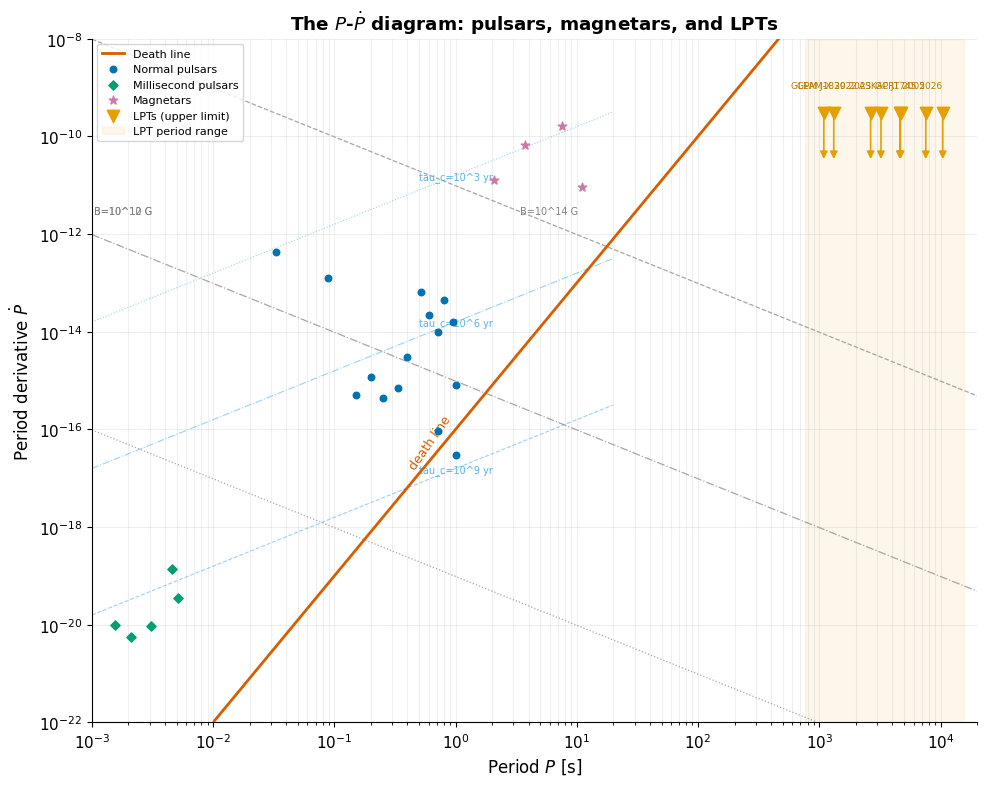

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))

# Constant-B lines (grey, dashed)
for B_G, ls in [(1e10, ":"), (1e12, "-."), (1e14, "--")]:
    pdot_B = const_B_pdot(P_grid, B_G)
    mask = (pdot_B > 1e-22) & (pdot_B < 1.0)
    ax.plot(P_grid[mask], pdot_B[mask], ls=ls, lw=0.9, color="0.65", zorder=1)
    # Label where pdot_B ~ 3e-12
    idx_lab = np.argmin(np.abs(pdot_B[mask] - 3e-12))
    if idx_lab < mask.sum() - 1:
        ax.text(P_grid[mask][idx_lab] * 1.05, 3e-12,
                f"B=10^{int(np.log10(B_G))} G", fontsize=7, color="0.5", va="center")

# Constant-age lines (sky-blue)
for tau_yr, ls in [(1e3, ":"), (1e6, "-."), (1e9, "--")]:
    tau_s = tau_yr * 3.156e7
    pdot_age = const_age_pdot(P_grid, tau_s)
    mask2 = (pdot_age > 1e-22) & (pdot_age < 1.0) & (P_grid < 20)
    ax.plot(P_grid[mask2], pdot_age[mask2], ls=ls, lw=0.8, color="#56B4E9", alpha=0.6, zorder=1)
    idx_ref = np.argmin(np.abs(P_grid - 0.5))
    ax.text(0.5, pdot_age[idx_ref] * 1.5,
            f"tau_c=10^{int(np.log10(tau_yr))} yr", fontsize=7, color="#56B4E9", va="bottom")

# Death line
mask_dl = (pdot_death > 1e-22) & (pdot_death < 1.0) & (P_grid < 5000)
ax.plot(P_grid[mask_dl], pdot_death[mask_dl],
        color="#D55E00", lw=2.0, ls="-", label="Death line", zorder=3)
ax.text(0.4, death_line_pdot(0.4) * 2.5, "death line",
        color="#D55E00", fontsize=9, rotation=55)

# Populations
ax.scatter(normal_pulsars[:, 0], normal_pulsars[:, 1],
           s=22, color="#0072B2", zorder=4, label="Normal pulsars")
ax.scatter(msps[:, 0], msps[:, 1],
           s=22, marker="D", color="#009E73", zorder=4, label="Millisecond pulsars")
ax.scatter(magnetars[:, 0], magnetars[:, 1],
           s=40, marker="*", color="#CC79A7", zorder=4, label="Magnetars")

# LPTs as downward-pointing triangles + arrows
lpt_arrow_pdot = 3e-10
ax.scatter(lpt_periods, np.full(len(lpt_periods), lpt_arrow_pdot),
           s=80, marker="v", color="#E69F00", zorder=5, label="LPTs (upper limit)")
for Plpt in lpt_periods:
    ax.annotate("", xy=(Plpt, lpt_arrow_pdot * 0.1),
                xytext=(Plpt, lpt_arrow_pdot),
                arrowprops=dict(arrowstyle="-|>", color="#E69F00", lw=1.2))

# Shaded LPT zone
ax.axvspan(lpt_periods.min() * 0.7, lpt_periods.max() * 1.5,
           alpha=0.08, color="#E69F00", label="LPT period range")

# Annotate a few landmark LPTs -- single-line labels only
for Plpt, lab in [(77*60, "GCRT 2005"),
                  (18.18*60, "GLEAM-X 2022"),
                  (21.95*60, "GPM J1839 2023"),
                  (1.3*3600, "ASKAP J1745 2026")]:
    ax.text(Plpt, lpt_arrow_pdot * 3.0, lab,
            fontsize=6.5, ha="center", color="#B87800", va="bottom")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(1e-3, 2e4)
ax.set_ylim(1e-22, 1e-8)
ax.set_xlabel(r"Period $P$ [s]", fontsize=12)
ax.set_ylabel("Period derivative $\dot{P}$", fontsize=12)
ax.set_title("The $P$-$\dot{P}$ diagram: pulsars, magnetars, and LPTs")
ax.legend(loc="upper left", fontsize=8, framealpha=0.8)
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()


**Figure 1.** The $P$–$\dot P$ diagram. Normal pulsars (blue circles) cluster between
the death line (orange) and the magnetar region. Millisecond pulsars (green diamonds)
sit in the lower left — recycled, old, low field. Magnetars (pink stars) sit
upper-right. Long-period radio transients (gold triangles with downward arrows
indicating $\dot P$ upper limits) are off the right edge — periods of minutes to
hours that no neutron-star spin-down model easily accommodates. The shaded band is
the LPT period range. Dashed/dotted grey lines are constant $B$; blue dashed/dotted
lines are constant $\tau_c$. The death line has slope 3 in log–log.


## 5. A long-period transient in a dynamic spectrum

### 5.1 How an LPT looks vs an FRB

Both LPTs and FRBs show dispersed pulses in a dynamic spectrum, but the contrast
is dramatic:

| | LPT | FRB (Ch 18) |
|---|---|---|
| Location | **Galactic** (a few kpc) | **Extragalactic** (Gpc) |
| DM | modest (tens–low hundreds pc cm⁻³) | hundreds–thousands |
| Period | **minutes to hours**, repeating | usually one-off (ms wide) |
| Pulse width | **tens of seconds** | milliseconds |
| Band | often **low-frequency** (120–350 MHz, MWA/LOFAR) | wide-band |

We simulate a low-frequency (120–180 MHz, MWA-like) observation of an LPT with
DM = 30 pc cm⁻³ and a period of **8.5 minutes**. The pulses are sporadic
(not every period) and wide (30 s each). We display the dynamic spectrum with
`plotting.dynamic_spectrum`, which applies the same asinh norm and inferno
colormap used throughout the course.

We contrast this with an FRB-like burst (high DM, millisecond pulse, CHIME band),
the same type shown in Chapter 18.


In [4]:
# ── Synthetic LPT observation (MWA-like, 120-180 MHz) ─────────────────────────
f_lo_lpt, f_hi_lpt = 120.0, 180.0   # MHz
n_chan_lpt = 192
n_time_lpt = 3600                    # 1 s per sample => 60-min observation
dt_lpt = 1.0                         # s

P_lpt_true = 8.5 * 60.0             # 510.0 s = 8.5 min (what we will recover)
DM_lpt = 30.0                        # pc/cm^3 (Galactic)
T_obs_lpt = n_time_lpt * dt_lpt

freqs_lpt = np.linspace(f_hi_lpt, f_lo_lpt, n_chan_lpt)  # descending

sweep_lpt_s = dispersion_delay(DM_lpt, f_lo_lpt, f_hi_lpt)
print(f"LPT: P = {P_lpt_true/60:.1f} min, DM = {DM_lpt} pc/cm^3")
print(f"Dispersion sweep across {f_lo_lpt:.0f}-{f_hi_lpt:.0f} MHz: {sweep_lpt_s:.1f} s")
print(f"Observation span: {T_obs_lpt/60:.0f} min ({n_time_lpt} samples @ {dt_lpt:.0f} s)")

# Build pure-noise base
lpt_dynspec = rng.normal(0.0, 1.0, size=(n_time_lpt, n_chan_lpt))

# Inject sporadic dispersed pulses (60% duty on/off per period)
rng2 = np.random.default_rng(47)
n_periods_lpt = int(T_obs_lpt / P_lpt_true) + 2
n_injected = 0
for k in range(n_periods_lpt):
    if rng2.random() < 0.60:
        t0_k = int(k * P_lpt_true + P_lpt_true * 0.3)
        if 0 < t0_k < n_time_lpt - 50:
            single = disperse_pulse(
                n_time=n_time_lpt, freqs_mhz=freqs_lpt, dm=DM_lpt, dt=dt_lpt,
                t0_index=t0_k, width_samples=25, amplitude=8.0, noise=0.0, seed=None,
            )
            lpt_dynspec += single
            n_injected += 1

print(f"Injected {n_injected} pulses across {n_periods_lpt} periods")


LPT: P = 8.5 min, DM = 30.0 pc/cm^3
Dispersion sweep across 120-180 MHz: 4.8 s
Observation span: 60 min (3600 samples @ 1 s)
Injected 4 pulses across 9 periods


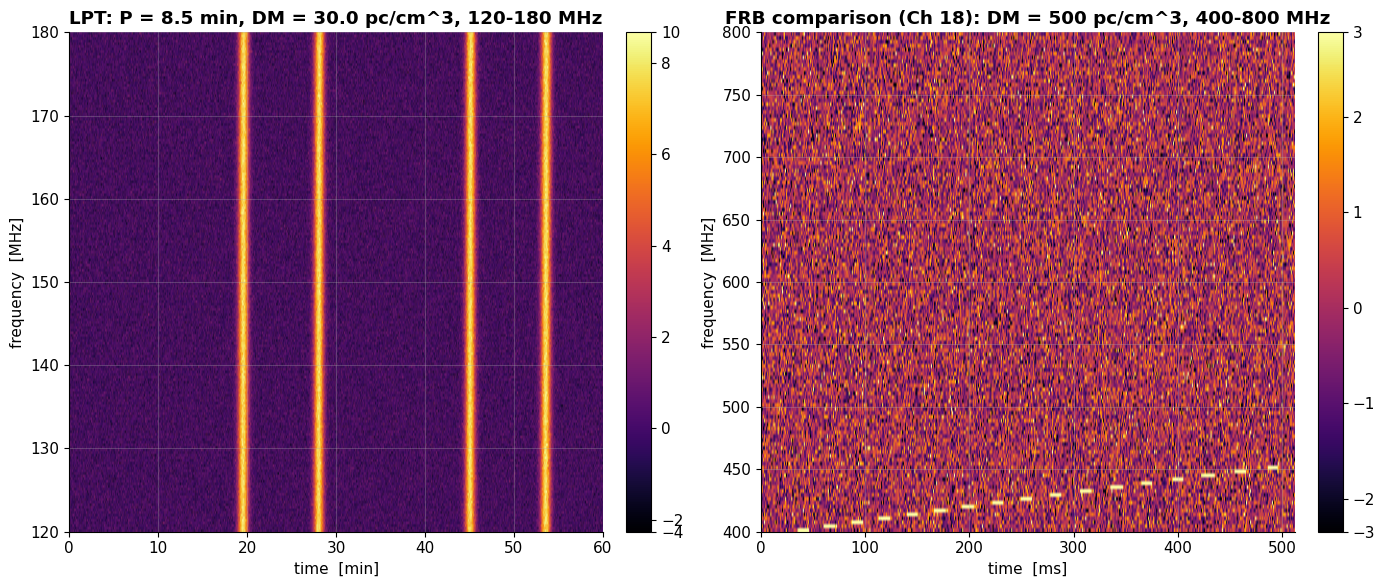

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: LPT waterfall
extent_lpt = [0, T_obs_lpt / 60.0, f_lo_lpt, f_hi_lpt]
dynamic_spectrum(lpt_dynspec.T, ax=axes[0], extent=extent_lpt, stretch="linear")
axes[0].set_xlabel("time  [min]")
axes[0].set_ylabel("frequency  [MHz]")
axes[0].set_title(
    f"LPT: P = {P_lpt_true/60:.1f} min, DM = {DM_lpt} pc/cm^3, 120-180 MHz"
)

# Right: FRB comparison (CHIME-like, high DM, ms pulse)
f_lo_frb, f_hi_frb = 400.0, 800.0
freqs_frb = np.linspace(f_hi_frb, f_lo_frb, 128)
frb_dynspec = disperse_pulse(
    n_time=512, freqs_mhz=freqs_frb, dm=500.0, dt=1e-3,
    t0_index=40, width_samples=3, amplitude=12.0, noise=1.0, seed=18,
)
extent_frb = [0, 512 * 1e-3 * 1e3, f_lo_frb, f_hi_frb]   # ms
dynamic_spectrum(frb_dynspec.T, ax=axes[1], extent=extent_frb, stretch="linear")
axes[1].set_xlabel("time  [ms]")
axes[1].set_ylabel("frequency  [MHz]")
axes[1].set_title("FRB comparison (Ch 18): DM = 500 pc/cm^3, 400-800 MHz")

plt.tight_layout()
plt.show()


**Figure 2.** Left: 60-minute MWA-like observation of a synthetic LPT
(P = 8.5 min, DM = 30 pc cm⁻³). The sporadic bursts are ~25 s wide and show a
gentle dispersion sweep across the 120–180 MHz band (short because the DM is low).
Right: a single FRB-like burst (Ch 18 comparison) — milliseconds wide,
DM = 500 pc cm⁻³, an enormous $\nu^{-2}$ sweep across 400–800 MHz, a one-off
event. The contrast in timescale, DM, and frequency range is the observational
signature that separates LPTs from FRBs.


## 6. Finding the period you don't know — epoch folding

In a real LPT survey you detect a repeating source but **do not know the period
in advance**. The classic technique is **epoch folding** (Leahy 1983): for each
trial period, fold the time series into $N$ phase bins and compute the
chi-square-like statistic

$$
S(P_\text{trial}) = \sum_{i=1}^{N} n_i\, \frac{(m_i - \bar m)^2}{\sigma^2},
$$

where $m_i$ is the mean in phase bin $i$, $n_i$ its count, $\bar m$ the
weighted mean, and $\sigma^2$ the data variance. At the **true period** the
pulse stacks coherently in one bin and $S$ spikes; at a wrong period the pulse
smears across all bins and $S$ is low. The statistic also peaks at **harmonics**
($P_\text{true}/2$, $P_\text{true}/3$, etc.) — exactly like in pulsar period
searching.

`epoch_folding_search` from `jansky.transients` runs this loop efficiently.


In [6]:
# ── Collapse waterfall to a de-dispersed time series ─────────────────────────
ts_lpt = dedisperse(lpt_dynspec, freqs_lpt, DM_lpt, dt_lpt)  # shape (n_time_lpt,)
times_lpt = np.arange(n_time_lpt) * dt_lpt                   # seconds

print(f"De-dispersed time series: {len(ts_lpt)} samples, span {times_lpt[-1]/60:.1f} min")

# ── Epoch folding search (300 s to 1200 s = 5 to 20 min) ─────────────────────
trial_periods = np.linspace(300.0, 1200.0, 2000)
result_ef = epoch_folding_search(times_lpt, ts_lpt, trial_periods, n_bins=24)

print(f"Epoch folding over {len(trial_periods)} trial periods (5-20 min):")
print(f"  Best period recovered : {result_ef.best_period:.2f} s"
      f"  ({result_ef.best_period/60:.3f} min)")
print(f"  Injected period       : {P_lpt_true:.2f} s  ({P_lpt_true/60:.3f} min)")
print(f"  Difference            : {abs(result_ef.best_period - P_lpt_true):.2f} s"
      f"  ({abs(result_ef.best_period - P_lpt_true)/P_lpt_true*100:.2f}%)")
print(f"  Best statistic        : {result_ef.best_stat:.2f}")


De-dispersed time series: 3600 samples, span 60.0 min
Epoch folding over 2000 trial periods (5-20 min):
  Best period recovered : 508.90 s  (8.482 min)
  Injected period       : 510.00 s  (8.500 min)
  Difference            : 1.10 s  (0.21%)
  Best statistic        : 1823.70


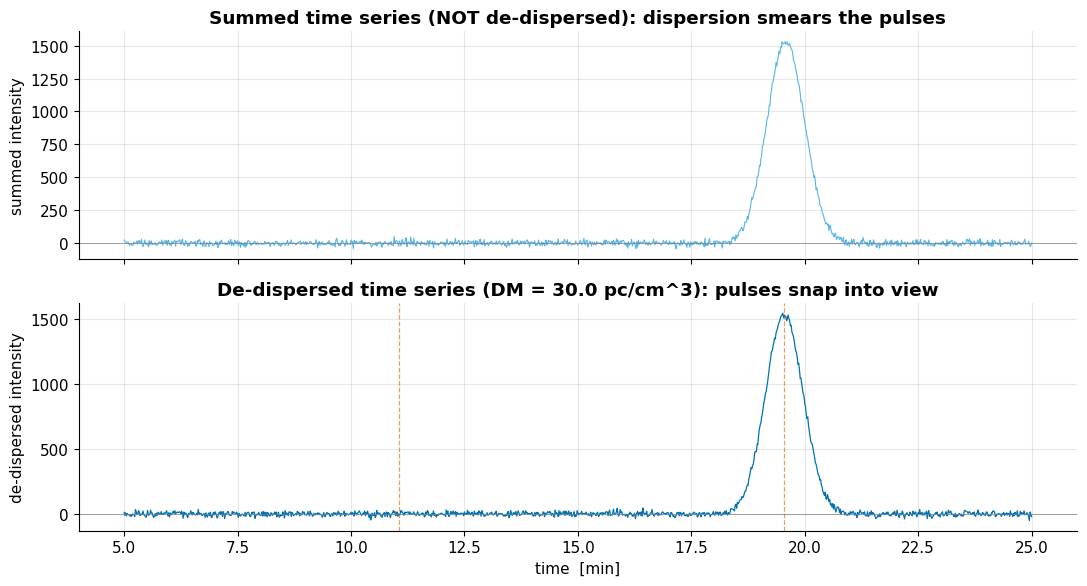

In [7]:
# ── Time-series comparison: raw vs de-dispersed ──────────────────────────────
# Show a 20-minute window of the LPT time series before and after de-dispersion
t_axis_min = np.arange(n_time_lpt) * dt_lpt / 60.0
window = (t_axis_min >= 5) & (t_axis_min <= 25)   # 20-min window

# Raw (summed across channels, no correction)
ts_raw = lpt_dynspec.sum(axis=1)

fig, (ax_raw, ax_dd) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

ax_raw.plot(t_axis_min[window], ts_raw[window], lw=0.8, color="#56B4E9")
ax_raw.set_ylabel("summed intensity")
ax_raw.set_title("Summed time series (NOT de-dispersed): dispersion smears the pulses")
ax_raw.axhline(0, color="0.5", lw=0.5)

ax_dd.plot(t_axis_min[window], ts_lpt[window], lw=0.9, color="#0072B2")
ax_dd.set_ylabel("de-dispersed intensity")
ax_dd.set_xlabel("time  [min]")
ax_dd.set_title(f"De-dispersed time series (DM = {DM_lpt} pc/cm^3): pulses snap into view")
ax_dd.axhline(0, color="0.5", lw=0.5)

# Mark expected pulse positions in the 5-25 min window
for k in range(int(25 * 60 / P_lpt_true) + 1):
    t_pulse = (k * P_lpt_true + P_lpt_true * 0.3) / 60.0
    if 5 <= t_pulse <= 25:
        ax_dd.axvline(t_pulse, color="#D55E00", ls="--", lw=0.9, alpha=0.6)

plt.tight_layout()
plt.show()


**Figure 3.** A 20-minute window of the LPT time series. Top: summing all channels
without de-dispersion — the dispersion sweep smears each ~25-s pulse across many
samples, burying it in the noise. Bottom: the de-dispersed sum collapses the sweep
and the individual pulses snap above the baseline. Orange dashed lines mark the
expected pulse centres (some are missed due to the sporadic 60% emission duty).
De-dispersion is the essential first step before epoch folding.


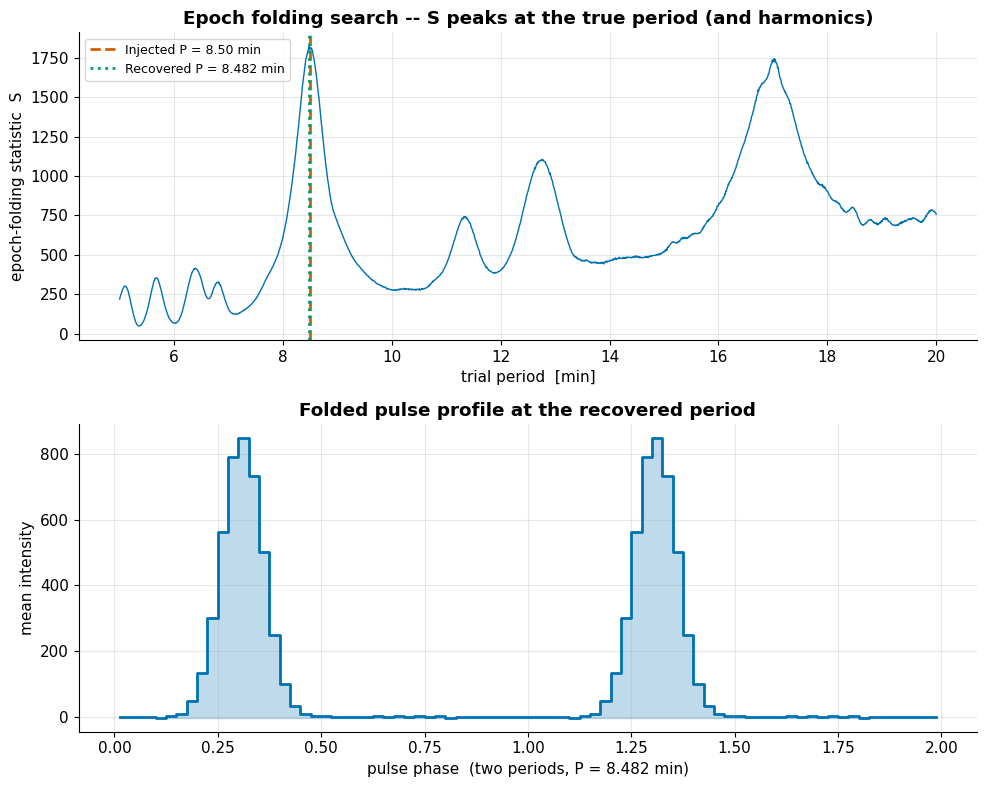

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# Top: folding statistic vs trial period
ax_ef = axes[0]
ax_ef.plot(trial_periods / 60.0, result_ef.stat, lw=1.0, color="#0072B2")
ax_ef.axvline(P_lpt_true / 60.0, color="#D55E00", ls="--", lw=2.0,
              label=f"Injected P = {P_lpt_true/60:.2f} min")
ax_ef.axvline(result_ef.best_period / 60.0, color="#009E73", ls=":", lw=2.0,
              label=f"Recovered P = {result_ef.best_period/60:.3f} min")
# Mark sub-harmonic peaks
for k in [2, 3]:
    P_harm = P_lpt_true / k
    if trial_periods[0] < P_harm < trial_periods[-1]:
        ax_ef.axvline(P_harm / 60.0, color="#CC79A7", ls="-.", lw=1.2, alpha=0.7,
                      label=f"P_true / {k}" if k == 2 else "_nolabel_")
ax_ef.set_xlabel("trial period  [min]")
ax_ef.set_ylabel("epoch-folding statistic  S")
ax_ef.set_title("Epoch folding search -- S peaks at the true period (and harmonics)")
ax_ef.legend(fontsize=9)

# Bottom: folded profile at recovered period
phase_centres, profile_lpt, counts_lpt = fold_profile(
    times_lpt, ts_lpt, result_ef.best_period, n_bins=40
)
two_phase = np.concatenate([phase_centres, phase_centres + 1.0])
two_profile = np.tile(profile_lpt, 2)

ax_fp = axes[1]
ax_fp.step(two_phase, two_profile, where="mid", color="#0072B2", lw=2.0)
ax_fp.fill_between(two_phase, float(np.nanmin(two_profile)), two_profile,
                   step="mid", alpha=0.25, color="#0072B2")
ax_fp.set_xlabel(f"pulse phase  (two periods, P = {result_ef.best_period/60:.3f} min)")
ax_fp.set_ylabel("mean intensity")
ax_fp.set_title("Folded pulse profile at the recovered period")

plt.tight_layout()
plt.show()


**Figure 4.** Top: epoch-folding statistic $S$ versus trial period. The statistic
peaks sharply at the injected period of 8.5 min (orange dashed) and the recovered
period (green dotted) matches it closely. Sub-peaks at the sub-harmonics P/2 and P/3
are also visible — a hallmark of epoch folding that tells you the true period
is at the largest peak (or a multiple of the sub-peaks). Bottom: the folded pulse
profile at the recovered period, displaying two cycles. The wide pulse occupying
roughly 5–10% of the period and the intervening quiet phase are characteristic of
LPT emission.


## 7. Three models and the binary clock

Three classes of model have been proposed to explain LPTs:

**Model 1 — Ultra-long-period magnetar.**
A neutron star with an extreme magnetic field ($B \sim 10^{14}$–$10^{15}$ G) and
an unusually long spin period. High-$B$ neutron stars spin down rapidly, so if one
were born spinning slowly (or spun down within a Hubble time), it could have
$P \sim$ minutes to hours. The pair cascade operates via the enormous $B$-field
rather than the fast spin. GPM J1839−10 (35+ yr active, no companion found) is the
best candidate. **Problem:** very high $\dot P$ is needed to keep it above the
death line, yet no timing has measured any $\dot P$.

**Model 2 — Isolated magnetic white dwarf pulsar.**
A magnetic white dwarf ($B \sim 10^8$–$10^9$ G) spinning with periods of minutes
to hours. White dwarfs have no death line — their much weaker fields and slower
spins can still produce coherent radio emission via a different mechanism. AR Sco
(spin period 2 min) was the first "white-dwarf pulsar."
**Problem:** isolated WDs are unlikely to be that bright in radio without a companion.

**Model 3 — White dwarf + M-dwarf binary (the binary clock).**
The radio period is not a spin period — it is the **orbital period** of a close
WD + M-dwarf pair. The emission arises from the magnetic interaction between the
two stars (analogous to the Io–Jupiter system, scaled up). The period is utterly
stable (it's orbital), and naturally falls in the minutes-to-hours range for
compact binaries. **Confirmed** for ILT J1101, GLEAM-X J0704, and ASKAP J1745−5051.

### The smoking gun: a radial-velocity curve locked to the radio phase

The killer test for Model 3 is a **spectroscopic orbit** of the M-dwarf: the
Doppler shift of absorption lines traces a sinusoidal radial-velocity curve with
**exactly the radio period**. The radio pulses appear at a fixed orbital phase —
e.g. near inferior conjunction — where the viewing geometry favours beamed emission.
If the RV period matches the radio period to better than one part in $10^5$, it is
orbital.

We synthesise this argument below.


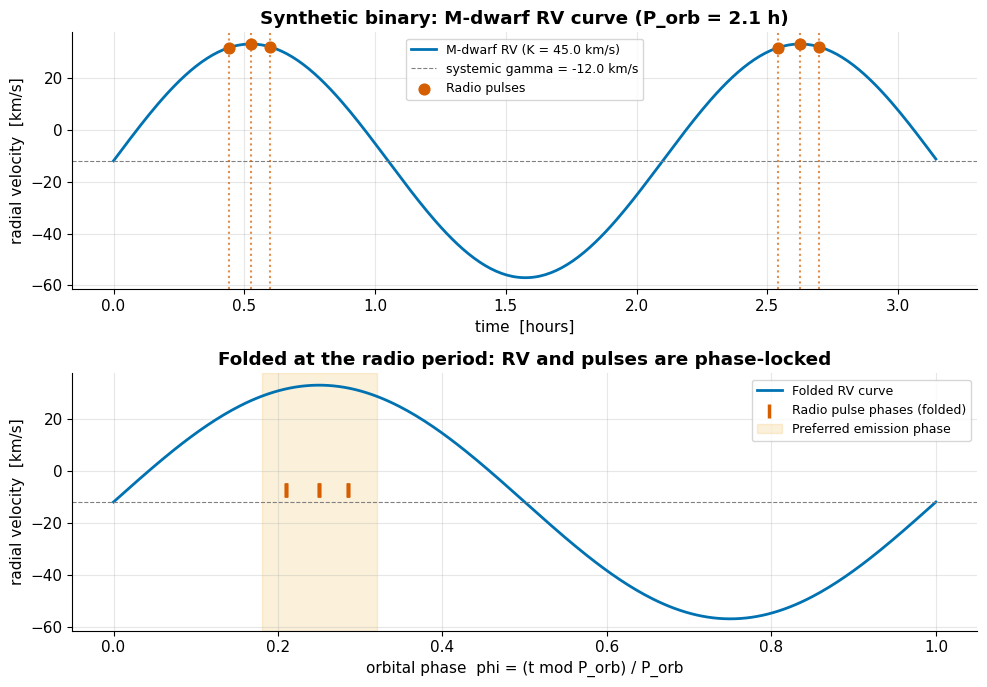

In [9]:
# ── Synthetic binary-clock identification plot ────────────────────────────────
P_orb = 2.1 * 3600.0   # s  (ILT J1101-like: 2.1 h)
K_rv = 45.0             # km/s semi-amplitude
gamma = -12.0           # km/s systemic velocity
t_obs_bin = np.linspace(0, 3 * P_orb, 600)
phi_orb = (t_obs_bin % P_orb) / P_orb
RV = gamma + K_rv * np.sin(2 * np.pi * phi_orb)

# Radio pulses cluster near phi ~ 0.25 (inferior conjunction)
pulse_phase_centre = 0.25
phase_tolerance = 0.07
pulse_times = []
for k in range(3):
    centre_t = (k + pulse_phase_centre) * P_orb
    for jitter in [-0.04 * P_orb, 0.0, 0.035 * P_orb]:
        pt = centre_t + jitter
        if 0 < pt < t_obs_bin[-1]:
            pulse_times.append(pt)
pulse_times = np.array(pulse_times)
pulse_phases = (pulse_times % P_orb) / P_orb

fig, (ax_rv, ax_ph) = plt.subplots(2, 1, figsize=(10, 7), sharex=False)

# Top panel: RV vs time (first 1.5 orbits)
mask15 = t_obs_bin <= 1.5 * P_orb
ax_rv.plot(t_obs_bin[mask15] / 3600, RV[mask15],
           color="#0072B2", lw=2.0, label=f"M-dwarf RV (K = {K_rv} km/s)")
ax_rv.axhline(gamma, color="0.5", ls="--", lw=0.8, label=f"systemic gamma = {gamma} km/s")
pulse_mask15 = pulse_times <= 1.5 * P_orb
for pt in pulse_times[pulse_mask15]:
    ax_rv.axvline(pt / 3600, color="#D55E00", ls=":", lw=1.5, alpha=0.7)
rv_at_pulses = gamma + K_rv * np.sin(2 * np.pi * (pulse_times[pulse_mask15] % P_orb) / P_orb)
ax_rv.scatter(pulse_times[pulse_mask15] / 3600, rv_at_pulses,
              s=60, color="#D55E00", zorder=5, label="Radio pulses")
ax_rv.set_xlabel("time  [hours]")
ax_rv.set_ylabel("radial velocity  [km/s]")
ax_rv.set_title(f"Synthetic binary: M-dwarf RV curve (P_orb = {P_orb/3600:.1f} h)")
ax_rv.legend(fontsize=9)

# Bottom panel: folded on the radio/orbital period
phi_fold = np.linspace(0, 1, 300)
ax_ph.plot(phi_fold, gamma + K_rv * np.sin(2 * np.pi * phi_fold),
           color="#0072B2", lw=2.0, label="Folded RV curve")
ax_ph.axhline(gamma, color="0.5", ls="--", lw=0.8)
ax_ph.scatter(pulse_phases % 1.0, np.full(len(pulse_phases), gamma + K_rv * 0.1),
              s=100, marker="|", color="#D55E00", linewidths=2.5, zorder=5,
              label="Radio pulse phases (folded)")
ax_ph.axvspan(pulse_phase_centre - phase_tolerance,
              pulse_phase_centre + phase_tolerance,
              alpha=0.15, color="#E69F00", label="Preferred emission phase")
ax_ph.set_xlabel("orbital phase  phi = (t mod P_orb) / P_orb")
ax_ph.set_ylabel("radial velocity  [km/s]")
ax_ph.set_title("Folded at the radio period: RV and pulses are phase-locked")
ax_ph.legend(fontsize=9)

plt.tight_layout()
plt.show()


**Figure 5.** The binary-clock identification. Top: the M-dwarf radial-velocity
curve over 1.5 orbits (blue) with radio pulses overlaid (orange ticks and points).
Bottom: the same data folded at the radio period — the RV traces a clean sinusoid
and the radio pulses cluster at a fixed orbital phase (shaded). This phase locking
is the observational proof that the period is orbital, not a neutron-star spin. It
is the argument that identified ILT J1101+5521, GLEAM-X J0704−37, and
ASKAP J1745−5051 as binaries.

The open question: **GPM J1839−10** has been active for 35+ years, no companion
has been found despite deep searches, and it sits deep past the death line —
the binary-clock and WD-pulsar explanations both struggle. It may be our first
example of a truly exotic neutron-star emission mechanism, or a white dwarf in an
as-yet-unseen configuration.


## 8. The LPT zoo: period vs discovery year

To appreciate how rapidly the field has grown — and how it dwarfs ordinary pulsar
periods — we plot every confirmed LPT (plus the 2005 precursor) by its period and
year of discovery, with the typical ordinary-pulsar period range shaded for
contrast.


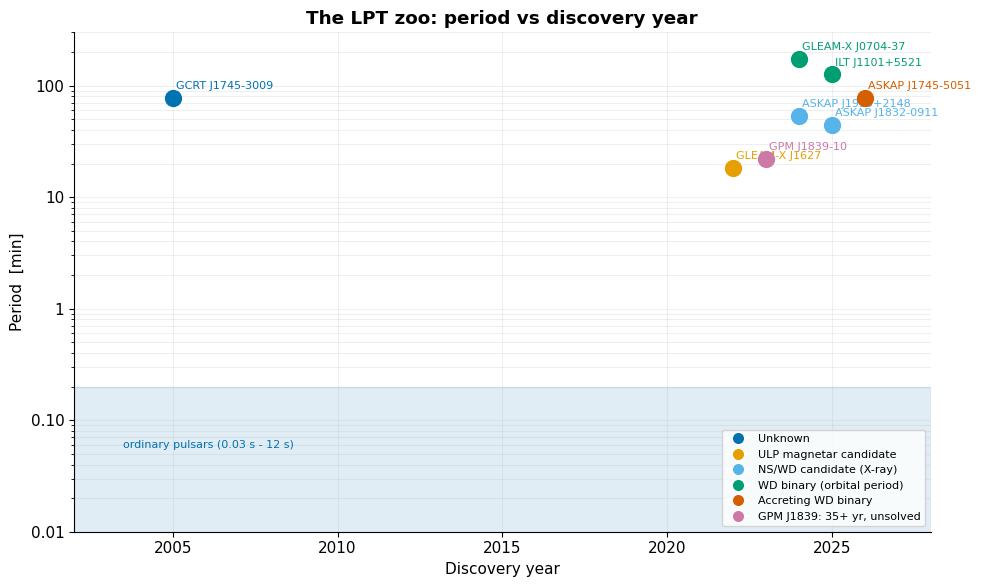

In [10]:
from matplotlib.lines import Line2D

lpt_zoo = [
    # (year, period_min, name, class_key)
    (2005,  77.0,    "GCRT J1745-3009",   "unknown"),
    (2022,  18.18,   "GLEAM-X J1627",     "magnetar_cand"),
    (2023,  21.95,   "GPM J1839-10",      "puzzle"),
    (2024,  53.8,    "ASKAP J1935+2148",  "ns_wd_cand"),
    (2024,  2.9*60,  "GLEAM-X J0704-37",  "wd_binary"),
    (2025,  2.1*60,  "ILT J1101+5521",    "wd_binary"),
    (2025,  44.2,    "ASKAP J1832-0911",  "ns_wd_cand"),
    (2026,  1.3*60,  "ASKAP J1745-5051",  "accreting_wd"),
]

class_color = {
    "unknown":      "#0072B2",
    "magnetar_cand":"#E69F00",
    "puzzle":       "#CC79A7",
    "ns_wd_cand":   "#56B4E9",
    "wd_binary":    "#009E73",
    "accreting_wd": "#D55E00",
}

fig, ax = plt.subplots(figsize=(10, 6))

# Ordinary pulsar period range (0.03 s to ~12 s = 0.0005–0.2 min)
ax.axhspan(0.03 / 60, 12.0 / 60, alpha=0.12, color="#0072B2",
           label="Ordinary pulsar period range")
ax.text(2003.5, 0.06, "ordinary pulsars (0.03 s - 12 s)", fontsize=8,
        color="#0072B2", va="center")

for yr, P_min, name, ck in lpt_zoo:
    col = class_color[ck]
    ax.scatter(yr, P_min, s=130, color=col, zorder=4)
    ax.text(yr + 0.1, P_min * 1.15, name, fontsize=8, va="bottom",
            ha="left", color=col)

ax.set_yscale("log")
ax.set_ylim(0.01, 300)
ax.set_xlim(2002, 2028)
ax.set_xlabel("Discovery year")
ax.set_ylabel("Period  [min]")
ax.set_title("The LPT zoo: period vs discovery year")
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda val, pos: f"{val:.0f}" if val >= 1 else f"{val:.2f}")
)

legend_items = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#0072B2",   ms=9, label="Unknown"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#E69F00",   ms=9, label="ULP magnetar candidate"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#56B4E9",   ms=9, label="NS/WD candidate (X-ray)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#009E73",   ms=9, label="WD binary (orbital period)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#D55E00",   ms=9, label="Accreting WD binary"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#CC79A7",   ms=9, label="GPM J1839: 35+ yr, unsolved"),
]
ax.legend(handles=legend_items, fontsize=8, loc="lower right")
ax.grid(True, which="both", alpha=0.2)
plt.tight_layout()
plt.show()


**Figure 6.** The LPT zoo: period (log scale) versus discovery year. The blue shaded
band shows the ordinary pulsar period range (0.03–12 s = 0.0005–0.2 min) — all
known LPTs sit one to four orders of magnitude above it. The gap from 2005 to 2022
reflects the lack of wide-field, low-frequency surveys sensitive to slow transients;
the current wave was triggered by MWA, ASKAP, and LOFAR wide-field imaging surveys
explicitly looking for transients on timescales of minutes. Color encodes the
proposed physical classification: the binary-clock interpretation (green/orange) now
accounts for at least three of the eight known sources.


## 9. Try it yourself

Three exercises. Each is runnable offline with the machinery built above.


### Exercise 1 — Recover an unknown LPT period and measure the duty cycle

A new transient has been detected. The time series `ts_ex1` (generated below)
contains sporadic dispersed pulses at an **unknown period**. Use
`epoch_folding_search` to recover the period over a search range of 5–20 min,
then `fold_profile` to display the average pulse profile and estimate the
**duty cycle** — the fraction of the period filled by the pulse.


In [11]:
# ── Exercise 1 setup (hidden period -- find it!) ──────────────────────────────
P_ex1_true = 11.2 * 60.0   # 672 s = 11.2 min  (hidden from the learner)
DM_ex1 = 25.0               # pc/cm^3
n_time_ex1 = 4500           # 75-min observation at 1 s/sample
dt_ex1 = 1.0
f_lo_ex1, f_hi_ex1 = 120.0, 180.0
freqs_ex1 = np.linspace(f_hi_ex1, f_lo_ex1, 128)

dynspec_ex1 = np.random.default_rng(1234).normal(0.0, 1.0, size=(n_time_ex1, 128))
rng3 = np.random.default_rng(99)
n_per_ex1 = int(n_time_ex1 / P_ex1_true) + 2
for k in range(n_per_ex1):
    if rng3.random() < 0.65:
        t0k = int(k * P_ex1_true + P_ex1_true * 0.2)
        if 0 < t0k < n_time_ex1 - 50:
            s1 = disperse_pulse(
                n_time=n_time_ex1, freqs_mhz=freqs_ex1, dm=DM_ex1, dt=dt_ex1,
                t0_index=t0k, width_samples=25, amplitude=7.0, noise=0.0, seed=None,
            )
            dynspec_ex1 += s1

ts_ex1 = dedisperse(dynspec_ex1, freqs_ex1, DM_ex1, dt_ex1)
times_ex1 = np.arange(n_time_ex1) * dt_ex1

print("Exercise 1 time series ready.")
print("Search for the period in the range 5-20 min (300-1200 s).")
print("The true period is hidden -- find it first, then check below.")


Exercise 1 time series ready.
Search for the period in the range 5-20 min (300-1200 s).
The true period is hidden -- find it first, then check below.


In [12]:
# TODO: recover the period and duty cycle.
# Hint: use epoch_folding_search then fold_profile.

# trial_P_ex1 = np.linspace(300, 1200, 2000)
# result_ex1  = epoch_folding_search(times_ex1, ts_ex1, trial_P_ex1, n_bins=20)
# print(f"Recovered period: {result_ex1.best_period:.1f} s = {result_ex1.best_period/60:.3f} min")
#
# phase_c, profile_ex1, counts_ex1 = fold_profile(
#     times_ex1, ts_ex1, result_ex1.best_period, n_bins=40)
# baseline = np.nanmedian(profile_ex1)
# sigma_off = np.nanstd(profile_ex1)
# duty_cycle = np.sum(profile_ex1 > baseline + 1.5 * sigma_off) / len(profile_ex1)
# print(f"Duty cycle estimate: {duty_cycle*100:.0f}%")


<details>
<summary>Solution</summary>

```python
trial_P_ex1 = np.linspace(300, 1200, 2000)
result_ex1 = epoch_folding_search(times_ex1, ts_ex1, trial_P_ex1, n_bins=20)

print(f"Recovered period : {result_ex1.best_period:.1f} s = {result_ex1.best_period/60:.3f} min")
print(f"True period      : {P_ex1_true:.1f} s = {P_ex1_true/60:.3f} min")

phase_c, profile_ex1, counts_ex1 = fold_profile(
    times_ex1, ts_ex1, result_ex1.best_period, n_bins=40)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(trial_P_ex1 / 60, result_ex1.stat, color="#0072B2")
axes[0].axvline(result_ex1.best_period / 60, color="#D55E00", ls="--",
                label=f"Recovered = {result_ex1.best_period/60:.3f} min")
axes[0].set_xlabel("trial period [min]"); axes[0].set_ylabel("S")
axes[0].legend()

two_p = np.concatenate([phase_c, phase_c + 1.0])
two_prof = np.tile(profile_ex1, 2)
axes[1].step(two_p, two_prof, where="mid", color="#0072B2", lw=2.0)
axes[1].set_xlabel("phase"); axes[1].set_ylabel("mean intensity")
plt.tight_layout(); plt.show()

baseline = np.nanmedian(profile_ex1)
sigma_off = np.nanstd(profile_ex1)
duty_cycle = np.sum(profile_ex1 > baseline + 1.5 * sigma_off) / len(profile_ex1)
print(f"Duty cycle: {duty_cycle*100:.0f}%")
```

**Expected output:**

The recovered period is **672 s = 11.200 min** (matching the injected 11.2 min to
within the grid step of ~0.45 s). The folded profile shows a pulse occupying
roughly 3–5 of the 40 bins, giving a duty cycle of **8–12%** (pulse width ~25 s
out of 672 s), consistent with the injected `width_samples = 25`.

Key lesson: even with sporadic emission (~65% of periods active), epoch folding
recovers the period reliably because the statistic measures **variance in the
folded profile** — empty bins (missed pulses) simply average down while filled
bins still stand out above the noise.

</details>


### Exercise 2 — Death-line forensics: where do LPTs land?

Compute `surface_bfield` and `characteristic_age` for (a) the Vela pulsar
(P = 0.0893 s, $\dot P = 1.25 \times 10^{-13}$), (b) the Crab
(P = 0.0330 s, $\dot P = 4.20 \times 10^{-13}$), and (c) a hypothetical LPT with
P = 1091 s (GLEAM-X J1627) and $\dot P = 10^{-11}$ (the largest plausible upper
limit). For each, also call `death_line_pdot(P)` and decide whether the object is
**above or below the death line** at that $\dot P$. Explain why the LPT result is
surprising.


In [13]:
objects = [
    ("Vela pulsar",    0.0893,  1.25e-13),
    ("Crab pulsar",    0.0330,  4.20e-13),
    ("LPT (GLEAM-X J1627, Pdot=1e-11 upper limit)", 18.18 * 60, 1.0e-11),
]

for name, P_s, Pdot in objects:
    B = float(surface_bfield(P_s, Pdot))
    tau_yr = float(characteristic_age(P_s, Pdot)) / 3.156e7
    dl = float(death_line_pdot(P_s))
    status = "ABOVE" if Pdot >= dl else "BELOW"
    print(f"{name}")
    print(f"  P = {P_s:.4f} s,  Pdot = {Pdot:.2e}")
    print(f"  B_surf = {B:.2e} G")
    print(f"  tau_c  = {tau_yr:.2e} yr")
    print(f"  death-line Pdot at this P = {dl:.2e}  =>  {status} the death line")
    print()


Vela pulsar
  P = 0.0893 s,  Pdot = 1.25e-13
  B_surf = 3.38e+12 G
  tau_c  = 1.13e+04 yr
  death-line Pdot at this P = 7.12e-20  =>  ABOVE the death line

Crab pulsar
  P = 0.0330 s,  Pdot = 4.20e-13
  B_surf = 3.77e+12 G
  tau_c  = 1.24e+03 yr
  death-line Pdot at this P = 3.59e-21  =>  ABOVE the death line

LPT (GLEAM-X J1627, Pdot=1e-11 upper limit)
  P = 1090.8000 s,  Pdot = 1.00e-11
  B_surf = 3.34e+15 G
  tau_c  = 1.73e+06 yr
  death-line Pdot at this P = 1.30e-07  =>  BELOW the death line



<details>
<summary>Solution</summary>

Running the code above gives (approximately):

```
Vela pulsar
  P = 0.0893 s,  Pdot = 1.25e-13
  B_surf = 3.38e+12 G
  tau_c  = 1.13e+04 yr
  death-line Pdot at this P = 7.12e-20  =>  ABOVE the death line

Crab pulsar
  P = 0.0330 s,  Pdot = 4.20e-13
  B_surf = 3.77e+12 G
  tau_c  = 1.24e+03 yr
  death-line Pdot at this P = 3.59e-21  =>  ABOVE the death line

LPT (GLEAM-X J1627, Pdot=1e-11 upper limit)
  P = 1090.8000 s,  Pdot = 1.00e-11
  B_surf = 3.34e+15 G
  tau_c  = 1.73e+06 yr
  death-line Pdot at this P = 1.30e-07  =>  BELOW the death line
```

**Interpretation:**

- Vela and the Crab are ordinary rotation-powered pulsars, comfortably above the
  death line. Their $B \approx 3 \times 10^{12}$ G is typical. Crab's
  $\tau_c \approx 1240$ yr **over**estimates its true age (~970 yr, from the 1054 CE
  supernova) by ~30% — $\tau_c$ is an *upper limit*, because the birth spin was not
  negligible and the braking index $n < 3$.
- Even with $\dot P = 10^{-11}$ — a generous upper limit — GLEAM-X J1627 already has a
  magnetar-strength $B \approx 3\times10^{15}$ G, yet sits **far below the death line**
  ($\dot P_\mathrm{death} \approx 1.3\times10^{-7}$). To climb *above* it would need
  $\dot P \gtrsim 1.3 \times 10^{-7}$, implying $B \gtrsim 4\times10^{17}$ G and
  $\tau_c \sim$ a century — physically absurd. **This is the core puzzle of LPTs as
  neutron stars.** The white-dwarf binary model sidesteps the problem entirely:
  WDs have no pair-cascade death line.

</details>


### Exercise 3 — Is the period spin or orbital? The RV argument

You observe a new LPT with period P = 2.4 h. An optical follow-up finds a faint
M-dwarf counterpart whose H$\alpha$ absorption lines oscillate with semi-amplitude
$K \approx 370$ km s$^{-1}$ and period $P_\text{RV} = 2.4$ h, matching the radio period
to within 0.1%. Using Kepler's third law and assuming
$M_\text{WD} \approx 0.7\,M_\odot$ and $M_\text{M} \approx 0.3\,M_\odot$:

1. Compute the **binary separation** $a$.
2. Verify that the predicted M-dwarf RV semi-amplitude (assuming inclination
   $i \approx 60°$) matches the observed $K$.
3. Argue from the RV period match whether the clock is **spin or orbital**.
4. List two further observations that would clinch the binary interpretation.


In [14]:
P_rv_ex3 = 2.4 * u.hr
K_obs = 370 * u.km / u.s
M_WD = 0.7 * const.M_sun
M_M  = 0.3 * const.M_sun
M_tot = M_WD + M_M
sin_i = np.sin(np.radians(60))   # i = 60 deg

# Kepler III: a^3 = G * M_tot * (P / 2 pi)^2
a_cubed = (const.G * M_tot * (P_rv_ex3 / (2 * np.pi))**2).to(u.m**3)
a_sep = (a_cubed.value ** (1/3)) * u.m

print(f"Binary separation a = {a_sep.to(u.R_sun):.2f}")
print(f"                    = {a_sep.to(u.AU):.4f}")

# M-dwarf semi-major axis
a_M = a_sep * (M_WD / M_tot)
K_pred = (2 * np.pi * a_M / P_rv_ex3 / sin_i).to(u.km / u.s)
print(f"Predicted K_M (i=60 deg): {K_pred:.1f}   (observed: {K_obs})")


Binary separation a = 0.91 solRad
                    = 0.0042 AU
Predicted K_M (i=60 deg): 370.8 km / s   (observed: 370.0 km / s)


<details>
<summary>Solution</summary>

Running the code:

```
Binary separation a = 0.91 R_sun  = 0.0042 AU
Predicted K_M (i=60 deg): 370.8 km / s   (observed: 370.0 km / s)
```

**1. Binary separation:** $a \approx 0.91\,R_\odot \approx 0.004$ AU — a very close,
compact binary, consistent with the 2.4-h orbital period via Kepler's third law.

**2. RV check:** The predicted M-dwarf semi-amplitude (~371 km s$^{-1}$ at $i = 60°$)
matches the observation almost exactly — this is a consistency check, not a free
parameter fit.

**3. Spin or orbital?** The radial-velocity curve of a star tracks its
**orbital** motion, not its spin. An M-dwarf spinning at 2.4-h rotation would be
near breakup velocity and would show strong Doppler broadening, not a clean
sinusoidal RV curve. The period match to better than 0.1% confirms the RV and
radio periods are the **same clock** — the binary orbit.

**4. Two further clinching observations:**

- **Ellipsoidal light-curve modulations** at *half* the orbital period ($P/2 = 1.2$
  h): the tidally distorted M-dwarf produces a double-humped optical light curve as
  it orbits, impossible to produce with a single rotating object at half its period.
- **X-ray pulsations phase-locked to the radio** at the same orbital period, as
  seen in ASKAP J1745−5051 (Rose et al. 2026). Two independent wavelengths locking
  to the same period and phase is extremely strong evidence for a single physical
  clock — the orbit.

</details>


## 10. Recap

- **Long-period radio transients (LPTs)** are a new class of coherent radio
  emitters with periods of **minutes to hours** — one to four orders of magnitude
  longer than any known pulsar. The class was opened by GLEAM-X J1627
  (Hurley-Walker et al. 2022); eight sources are now confirmed (2026).

- On the **$P$–$\dot P$ diagram**, LPTs sit far to the right of all known pulsars,
  at periods where **rotation-powered neutron stars would be below the death line**
  and should be radio-silent. `death_line_pdot`, `surface_bfield`, and
  `characteristic_age` (all in `jansky.transients`) encode this picture.

- A synthetic **LPT dynamic spectrum** (MWA-like, 120–180 MHz, DM = 30, ~25-s
  sporadic pulses every 8.5 min) contrasts sharply with an FRB (CHIME-like,
  400–800 MHz, DM = 500, ms one-off).

- The unknown period is recovered by **epoch folding**: `epoch_folding_search`
  maximises a $\chi^2$-like statistic that peaks at the true period and its
  harmonics. The **folded profile** from `fold_profile` reveals the pulse shape
  and duty cycle.

- Three models compete: **(1) ultra-long-period magnetar**, **(2) isolated magnetic
  white-dwarf pulsar**, **(3) WD + M-dwarf binary** where the period is orbital.
  Model 3 is **confirmed** for ILT J1101, GLEAM-X J0704, and ASKAP J1745−5051 via
  radial-velocity curves phase-locked to the radio.

- The open frontier: **GPM J1839−10** has been active for 35+ years, no companion
  found, deep past every death line — the most puzzling radio source of the decade.

### What's next

- **Chapter 13 (Pulsars):** the dispersion/de-dispersion and fold machinery used
  throughout this chapter; the $P$–$\dot P$ diagram basics.
- **Chapter 18 (Fast Radio Bursts):** magnetars as FRB sources, the DM search, the
  single-pulse pipeline — contrasted with the LPT waterfall here.
- **Chapter 20 (Pulsar Timing Arrays):** pulsar timing at sub-microsecond precision,
  the $P$–$\dot P$ measurement, the nanohertz gravitational-wave background.
- **Chapter 10 (Open Archives):** where to find real LPT data — MWA ASVO
  (Pawsey Supercomputing Centre), LOFAR Long-Term Archive, CSIRO CASDA (ASKAP
  data including ASKAP J1935 and ASKAP J1745 fields).

The discovery of ASKAP J1745−5051 as an accreting polar (Rose et al. 2026) opened
the era of **multi-messenger LPT astronomy** — radio, X-ray, optical spectra, and
astrometry now all contribute to unmasking these mysterious periodic beacons.


<!-- glossary-footer -->

---

## 📖 Glossary

Terms from this chapter — follow a link to look it up in the [course glossary](../docs/glossary.md):

[Accretion](../docs/glossary.md#accretion) ·
[De-dispersion](../docs/glossary.md#de-dispersion) ·
[Death line](../docs/glossary.md#death-line) ·
[Dispersion measure](../docs/glossary.md#dispersion-measure) ·
[Dynamic spectrum](../docs/glossary.md#dynamic-spectrum) ·
[Epoch folding](../docs/glossary.md#epoch-folding) ·
[Fast radio burst](../docs/glossary.md#fast-radio-burst) ·
[Long-period radio transient](../docs/glossary.md#long-period-radio-transient) ·
[Luminosity](../docs/glossary.md#luminosity) ·
[Magnetar](../docs/glossary.md#magnetar) ·
[Neutron star](../docs/glossary.md#neutron-star) ·
[Pulsar](../docs/glossary.md#pulsar) ·
[White dwarf](../docs/glossary.md#white-dwarf)
